In [19]:
# Essential libraries
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import math
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb

import shap
shap.initjs()

In [20]:
#connect to postgreSQL

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [21]:
df = pd.read_sql("SELECT * FROM orders_clean", engine)

df.shape
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub-category,product_name,sales,quantity,discount,profit,year,month,profit_margin
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,0.4700
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,0.1125


In [22]:
df.dtypes

row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date                   str
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub-category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
year                      int64
month                     int64
profit_margin           float64
dtype: object

In [23]:
df['category'] = df['category'].str.lower()
df['sub-category'] = df['sub-category'].str.lower()
df['region'] = df['region'].str.lower()
df['segment'] = df['segment'].str.lower()
df['ship_mode'] = df['ship_mode'].str.lower()

df.head(3)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub-category,product_name,sales,quantity,discount,profit,year,month,profit_margin
0,1,CA-2016-152156,2016-11-08,11/11/2016,second class,CG-12520,Claire Gute,consumer,United States,Henderson,...,furniture,bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,11,0.16
1,2,CA-2016-152156,2016-11-08,11/11/2016,second class,CG-12520,Claire Gute,consumer,United States,Henderson,...,furniture,chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,11,0.30
2,3,CA-2016-138688,2016-06-12,6/16/2016,second class,DV-13045,Darrin Van Huff,corporate,United States,Los Angeles,...,office supplies,labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016,6,0.47


In [24]:
#Creating a new data frame for only the columns needed for the model
df_model = df[['sales', 'quantity', 'discount', 'category', 'sub-category', 'region', 'segment', 'ship_mode', 'profit']].copy()

#Converting categorical columns into numbers for the model to read
df_model = pd.get_dummies(df_model, columns=['category', 'sub-category', 'region', 'segment', 'ship_mode'])

#Removing profit since that is what we are trying to predict & what i am trying to predict in y
X= df_model.drop(columns=['profit'])
y= df_model['profit']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modelling & Hyper-Parameter Tuning

In [26]:
xgb_model = xgb.XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42

)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [27]:
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mae)
r2 = r2_score(y_test,y_pred)

print(f"MAE: {round(mae, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"R2: {round(r2, 4)}")


MAE: 16.35
RMSE: 4.04
R2: 0.9271


In [28]:
print(X.columns.tolist())

['sales', 'quantity', 'discount', 'category_furniture', 'category_office supplies', 'category_technology', 'sub-category_accessories', 'sub-category_appliances', 'sub-category_art', 'sub-category_binders', 'sub-category_bookcases', 'sub-category_chairs', 'sub-category_copiers', 'sub-category_envelopes', 'sub-category_fasteners', 'sub-category_furnishings', 'sub-category_labels', 'sub-category_machines', 'sub-category_paper', 'sub-category_phones', 'sub-category_storage', 'sub-category_supplies', 'sub-category_tables', 'region_central', 'region_east', 'region_south', 'region_west', 'segment_consumer', 'segment_corporate', 'segment_home office', 'ship_mode_first class', 'ship_mode_same day', 'ship_mode_second class', 'ship_mode_standard class']


### Variable Importance

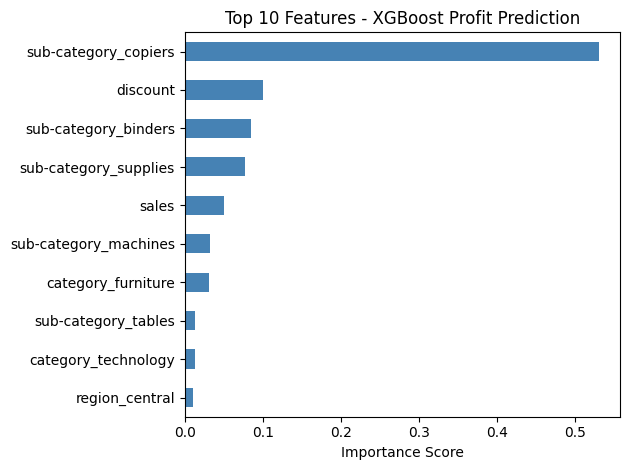

In [29]:
importances = pd.Series(xgb_model.feature_importances_, index= X.columns)

plt.Figure(figsize=(10,6))
importances.sort_values().tail(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Features - XGBoost Profit Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

XGBoost feature importance differs from that of the Random Forest model's.
Sub-Category copiers emerges as the dominant predictor (0.53), suggesting copier orders have a distinct profit profile
Discount remains consistently important across both models, confirming it as a reliable profite drirver.


#### Save Model

In [30]:
import pickle
import os

# This will show you exactly where it's saving
print(os.getcwd())

with open("xgboost_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Saved successfully")

e:\VSCode\Notebook\retail_sales_analytics
Saved successfully


### Model Comparison Summary 

In [31]:
# Model Comparison Summary
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Random Forest': [28.80, 118.11, 0.6842],
    'XGBoost': [16.35, 4.04, 0.9271]
})

comparison.set_index('Metric', inplace=True)

print("=" * 40)
print("      MODEL COMPARISON SUMMARY")
print("=" * 40)
print(comparison.to_string())
print("=" * 40)
print(f"\nMAE improvement:  {round((28.80 - 16.35) / 28.80 * 100, 1)}%")
print(f"RMSE improvement: {round((118.11 - 4.04) / 118.11 * 100, 1)}%")
print(f"R² improvement:   {round((0.9271 - 0.6842) / 0.6842 * 100, 1)}%")
print("\nConclusion: XGBoost selected as production model")

      MODEL COMPARISON SUMMARY
        Random Forest  XGBoost
Metric                        
MAE           28.8000  16.3500
RMSE         118.1100   4.0400
R²             0.6842   0.9271

MAE improvement:  43.2%
RMSE improvement: 96.6%
R² improvement:   35.5%

Conclusion: XGBoost selected as production model


#### SHAP Model

In [ ]:
# Renaming features before plotting

In [32]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X)

In [33]:
np.shape(shap_values.values)

(9994, 34)

34 Shap values for each of the 9994

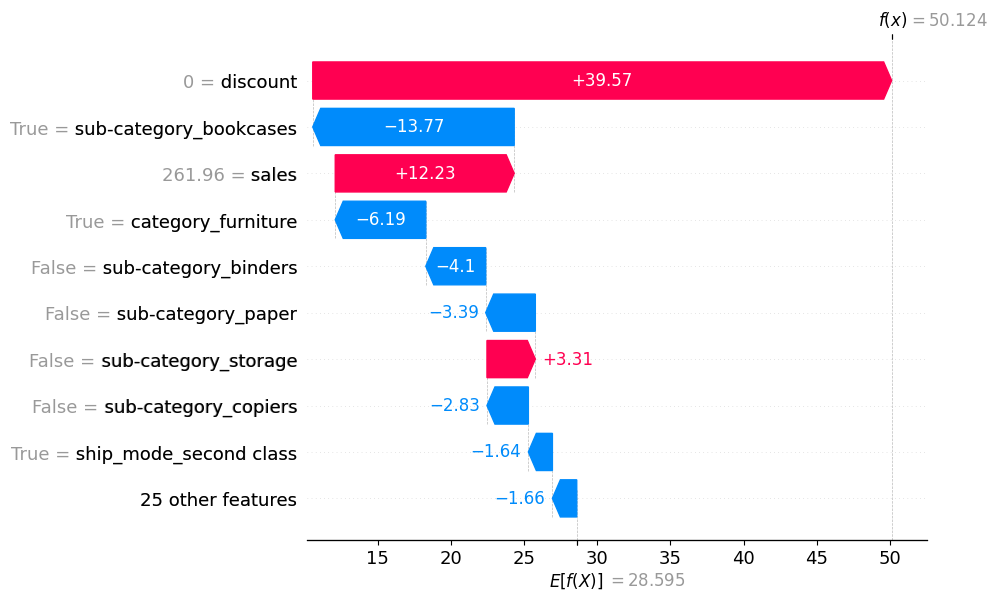

In [34]:
shap.plots.waterfall(shap_values[0])

Base average prediction is £28.59 

### Conclusion

XGBoost outperforms Random Forest across all three metrics.
The RMSE improvement of 96.6% is the most significant finding — 
XGBoost handles extreme profit outliers dramatically better than 
Random Forest, which was the primary weakness of the baseline model.

XGBoost will be used as the production model in the Streamlit deployment.